In [1]:
import numpy as np
import matplotlib.pyplot as plt
import copy
import math
from utils import * # Contient load_data, plot_data, map_feature, plot_decision_boundary

%matplotlib inline



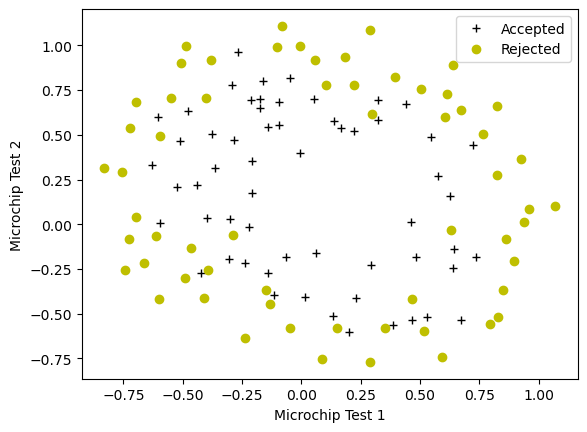

In [2]:
# Chargement des données
X_train, y_train = load_data("ex2data2.txt") 

# Feature Mapping : On crée des colonnes de polynômes pour une frontière non-linéaire
X_mapped = map_feature(X_train[:, 0], X_train[:, 1])

# Visualisation initiale
plot_data(X_train, y_train[:], pos_label="Accepted", neg_label="Rejected")
plt.ylabel('Microchip Test 2')
plt.xlabel('Microchip Test 1')
plt.legend(loc="upper right")
plt.show()



In [3]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def compute_cost(X, y, w, b, lambda_=1):
    m, n = X.shape
    cost = 0
    for i in range(m):
        z = np.dot(X[i], w) + b
        f_wb = sigmoid(z)
        cost += -y[i] * np.log(f_wb) - (1 - y[i]) * np.log(1 - f_wb)
    return cost / m

def compute_gradient(X, y, w, b, lambda_=None):
    m, n = X.shape
    dj_dw = np.zeros(w.shape)
    dj_db = 0.
    for i in range(m):
        f_wb_i = sigmoid(np.dot(X[i], w) + b)
        err_i = f_wb_i - y[i]
        for j in range(n):
            dj_dw[j] = dj_dw[j] + err_i * X[i, j]
        dj_db = dj_db + err_i
    return dj_db / m, dj_dw / m



In [4]:
def compute_cost_reg(X, y, w, b, lambda_=1):
    m, n = X.shape
    cost_without_reg = compute_cost(X, y, w, b)
    reg_cost = sum(np.square(w)) # Somme des carrés des poids
    total_cost = cost_without_reg + (lambda_ / (2 * m)) * reg_cost
    return total_cost

def compute_gradient_reg(X, y, w, b, lambda_=1):
    m, n = X.shape
    dj_db, dj_dw = compute_gradient(X, y, w, b)
    for j in range(n):
        dj_dw[j] = dj_dw[j] + (lambda_ / m) * w[j] # Ajustement du gradient
    return dj_db, dj_dw


In [5]:
def gradient_descent(X, y, w_in, b_in, cost_function, gradient_function, alpha, num_iters, lambda_):
    w = copy.deepcopy(w_in)
    b = b_in
    J_history = []
    
    for i in range(num_iters):
        dj_db, dj_dw = gradient_function(X, y, w, b, lambda_)
        w = w - alpha * dj_dw
        b = b - alpha * dj_db
        
        if i < 100000:
            J_history.append(cost_function(X, y, w, b, lambda_))
        if i % (num_iters // 10) == 0:
            print(f"Iteration {i:4}: Cost {float(J_history[-1]):8.2f}")
            
    return w, b, J_history




Iteration    0: Cost     0.72
Iteration 1000: Cost     0.59
Iteration 2000: Cost     0.56
Iteration 3000: Cost     0.53
Iteration 4000: Cost     0.51
Iteration 5000: Cost     0.50
Iteration 6000: Cost     0.48
Iteration 7000: Cost     0.47
Iteration 8000: Cost     0.46
Iteration 9000: Cost     0.45

Train Accuracy: 82.20%


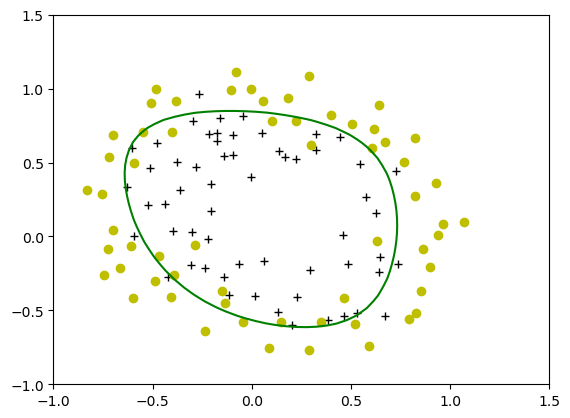

In [6]:
def predict(X, w, b):
    m, n = X.shape
    p = np.zeros(m)
    for i in range(m):
        z_wb = np.dot(X[i], w) + b
        f_wb = sigmoid(z_wb)
        p[i] = 1 if f_wb > 0.5 else 0 # Seuil de décision
    return p

#  Exécution finale
np.random.seed(1)
initial_w = np.random.rand(X_mapped.shape[1]) - 0.5
initial_b = 1.
lambda_ = 0.01
iterations = 10000
alpha = 0.01

# Apprentissage
w, b, J_history = gradient_descent(X_mapped, y_train, initial_w, initial_b, 
                                   compute_cost_reg, compute_gradient_reg, 
                                   alpha, iterations, lambda_)

# Précision et Graphique
p = predict(X_mapped, w, b)
print(f'\nTrain Accuracy: {np.mean(p == y_train) * 100:.2f}%')
plot_decision_boundary(w, b, X_mapped, y_train)


STREAMLIT

In [7]:
# import pickle

# # On sauvegarde les poids (w), le biais (b) et la fonction map_feature
# # pour pouvoir les réutiliser dans l'application
# model_data = {
#     "w": w,
#     "b": b
# }

# with open("model_logistic.pkl", "wb") as f:
#     pickle.dump(model_data, f)

# print("Modèle sauvegardé ")


In [11]:
import pickle
import numpy as np


w_simple = np.array([0.2, 0.2]) 
b_simple = -24.0

# On ecrase le fichier avec  2 paramètres
with open("model_etudiant.pkl", "wb") as f:
    pickle.dump({"w": w_simple, "b": b_simple}, f)

print("Modele sauvegardé",len(w), "poids")


Modele sauvegardé 27 poids
